In [1]:
# =========================
# 1. INSTALACIÓN
# =========================

!pip install -q transformers==4.40.2 datasets evaluate accelerate albumentations opencv-python pillow scikit-learn

In [1]:
# =========================
# 2. IMPORTS
# =========================

import os
import zipfile
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
import albumentations as A
import cv2
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

from transformers import (
    AutoImageProcessor,
    AutoModelForUniversalSegmentation,
    TrainingArguments,
    Trainer,
)

In [2]:
# =========================
# 3. CONFIGURACIÓN
# =========================

MODEL_NAME = "facebook/mask2former-swin-tiny-ade-semantic"

ZIP_DIR = Path("/content/cvat_zips")          # aquí metes los 15 zips
WORK_DIR = Path("/content/oranges_dataset")   # dataset procesado
OUTPUT_DIR = Path("/content/maskformer_oranges_final")

IMAGE_SIZE = 512

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42

BATCH_SIZE = 1
LEARNING_RATE = 1.5e-4
EPOCHS = 15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

WORK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# =========================
# 4. DESCOMPRIMIR ZIPs
# =========================

EXTRACT_DIR = WORK_DIR / "extracted"
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

for zip_path in ZIP_DIR.glob("*.zip"):
    task_name = zip_path.stem
    task_dir = EXTRACT_DIR / task_name
    task_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(task_dir)

print("ZIPs extraídos:", len(list(EXTRACT_DIR.iterdir())))

ZIPs extraídos: 15


In [4]:
# =========================
# 5. CONVERTIR POLYGONS CVAT A MÁSCARAS
# =========================

images_out = WORK_DIR / "images"
masks_out = WORK_DIR / "masks"

images_out.mkdir(parents=True, exist_ok=True)
masks_out.mkdir(parents=True, exist_ok=True)

def parse_points(points_str):
    points = []
    for p in points_str.split(";"):
        x, y = p.split(",")
        points.append([float(x), float(y)])
    return np.array(points, dtype=np.int32)

sample_id = 0

for task_dir in EXTRACT_DIR.iterdir():
    if not task_dir.is_dir():
        continue

    xml_path = task_dir / "annotations.xml"
    img_dir = task_dir / "images"

    if not xml_path.exists():
        print(f"No annotations.xml en {task_dir}")
        continue

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for image_node in root.findall("image"):
        img_name = image_node.attrib["name"]
        width = int(image_node.attrib["width"])
        height = int(image_node.attrib["height"])

        image_path = img_dir / img_name

        if not image_path.exists():
            print(f"No encontrada imagen: {image_path}")
            continue

        mask = np.zeros((height, width), dtype=np.uint8)

        for polygon in image_node.findall("polygon"):
            label = polygon.attrib.get("label", "")

            if label != "orange":
                continue

            points = parse_points(polygon.attrib["points"])
            cv2.fillPoly(mask, [points], 1)

        # Copiamos imagen y máscara con nombre único
        new_name = f"sample_{sample_id:05d}"

        image = Image.open(image_path).convert("RGB")
        image.save(images_out / f"{new_name}.jpg")

        Image.fromarray(mask).save(masks_out / f"{new_name}.png")

        sample_id += 1

print("Total muestras generadas:", sample_id)

Total muestras generadas: 225


In [5]:
# =========================
# 6. COMPROBAR MÁSCARAS
# =========================

mask_files = list(masks_out.glob("*.png"))

for p in mask_files[:5]:
    arr = np.array(Image.open(p))
    print(p.name, np.unique(arr))

orange_pixels = 0
total_pixels = 0

for p in mask_files:
    arr = np.array(Image.open(p))
    orange_pixels += (arr == 1).sum()
    total_pixels += arr.size

print("Ratio píxeles naranja:", orange_pixels / total_pixels)

sample_00216.png [0 1]
sample_00094.png [0 1]
sample_00136.png [0 1]
sample_00011.png [0 1]
sample_00126.png [0 1]
Ratio píxeles naranja: 0.02053794280042186


In [6]:
# =========================
# 7. SPLIT TRAIN / VAL / TEST
# =========================

all_samples = sorted([p.stem for p in images_out.glob("*.jpg")])

train_samples, temp_samples = train_test_split(
    all_samples,
    train_size=TRAIN_RATIO,
    random_state=SEED,
    shuffle=True,
)

val_size_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

val_samples, test_samples = train_test_split(
    temp_samples,
    train_size=val_size_adjusted,
    random_state=SEED,
    shuffle=True,
)

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))



Train: 157
Val: 34
Test: 34


In [7]:
# =========================
# 8. DATASET PYTORCH
# =========================

class OrangeSegmentationDataset(Dataset):
    def __init__(self, sample_ids, images_dir, masks_dir, processor, image_size=512, is_train=False):
        self.sample_ids = sample_ids
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.processor = processor
        self.image_size = image_size


    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]

        image = Image.open(self.images_dir / f"{sample_id}.jpg").convert("RGB")
        mask = Image.open(self.masks_dir / f"{sample_id}.png")

        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        image_np = np.array(image)
        mask_np = np.array(mask, dtype=np.int64)

        # Aseguramos clases limpias: 0 background, 1 orange
        mask_np = np.where(mask_np > 0, 1, 0).astype(np.int64)

        inputs = self.processor(
            images=image_np,
            segmentation_maps=mask_np,
            return_tensors="pt",
        )

        item = {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "mask_labels": inputs["mask_labels"],
            "class_labels": inputs["class_labels"],
            "original_mask": torch.tensor(mask_np, dtype=torch.long),
        }

        return item


def collate_fn(batch):
    pixel_values = torch.stack([x["pixel_values"] for x in batch])

    mask_labels = []
    class_labels = []

    for x in batch:
        mask_labels.append(x["mask_labels"][0])
        class_labels.append(x["class_labels"][0])

    return {
        "pixel_values": pixel_values,
        "mask_labels": mask_labels,
        "class_labels": class_labels,
    }

In [8]:
# =========================
# 9. MODELO Y PROCESSOR
# =========================

id2label = {
    0: "background",
    1: "orange",
}

label2id = {
    "background": 0,
    "orange": 1,
}

processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    do_reduce_labels=False,
    reduce_labels=False,
)

model = AutoModelForUniversalSegmentation.from_pretrained(
    MODEL_NAME,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

train_dataset = OrangeSegmentationDataset(
    train_samples,
    images_out,
    masks_out,
    processor,
    image_size=IMAGE_SIZE
)

val_dataset = OrangeSegmentationDataset(
    val_samples,
    images_out,
    masks_out,
    processor,
    image_size=IMAGE_SIZE
)

test_dataset = OrangeSegmentationDataset(
    test_samples,
    images_out,
    masks_out,
    processor,
    image_size=IMAGE_SIZE
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

The image processor of type `Mask2FormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/82.5k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-ade-semantic
Key                    | Status   |                                                                                       
-----------------------+----------+---------------------------------------------------------------------------------------
class_predictor.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151, 256]) vs model:torch.Size([3, 256])
class_predictor.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([3])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [9]:
# =========================
# 10. TRAINING
# =========================

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    save_strategy="epoch",
    eval_strategy="no",
    logging_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
)

trainer.train()

Step,Training Loss
157,14.969871
314,8.485073
471,7.882399
628,7.281014
785,6.892259
942,6.473401
1099,6.029507
1256,5.781224
1413,5.533827
1570,5.287791


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2355, training_loss=6.597757353246085, metrics={'train_runtime': 1131.3195, 'train_samples_per_second': 2.082, 'train_steps_per_second': 2.082, 'total_flos': 2.9596642442919936e+17, 'train_loss': 6.597757353246085, 'epoch': 15.0})

In [10]:
# =========================
# 11. GUARDAR MODELO FINAL
# =========================

FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"

trainer.save_model(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)

print("Modelo guardado en:", FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado en: /content/maskformer_oranges_final/final_model


In [11]:
# =========================
# 12. EVALUACIÓN IOU EN TEST
# =========================

def compute_iou(pred_mask, true_mask, class_id=1):
    pred = pred_mask == class_id
    true = true_mask == class_id

    intersection = np.logical_and(pred, true).sum()
    union = np.logical_or(pred, true).sum()

    if union == 0:
        return np.nan

    return intersection / union


model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

ious = []

for sample_id in test_samples:
    image = Image.open(images_out / f"{sample_id}.jpg").convert("RGB")
    true_mask = Image.open(masks_out / f"{sample_id}.png")

    original_size = true_mask.size[::-1]

    image_resized = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    true_mask_resized = true_mask.resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)

    image_np = np.array(image_resized)
    true_mask_np = np.array(true_mask_resized, dtype=np.int64)
    true_mask_np = np.where(true_mask_np > 0, 1, 0)

    inputs = processor(
        images=image_np,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = processor.post_process_semantic_segmentation(
        outputs,
        target_sizes=[(IMAGE_SIZE, IMAGE_SIZE)],
    )[0]

    pred_mask = pred.cpu().numpy()

    iou = compute_iou(pred_mask, true_mask_np, class_id=1)

    if not np.isnan(iou):
        ious.append(iou)

print("Test IoU orange:", np.mean(ious))
print("Número imágenes test evaluadas:", len(ious))

Test IoU orange: 0.7878052686470978
Número imágenes test evaluadas: 34


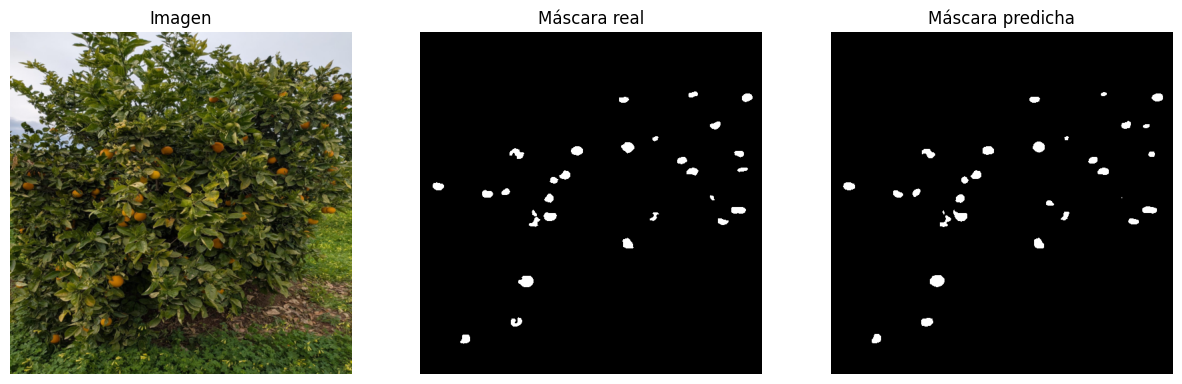

In [12]:
# =========================
# 13. VISUALIZAR PREDICCIONES
# =========================

import matplotlib.pyplot as plt

def show_prediction(sample_id):
    image = Image.open(images_out / f"{sample_id}.jpg").convert("RGB")
    true_mask = Image.open(masks_out / f"{sample_id}.png")

    image_resized = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)
    true_mask_resized = true_mask.resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)

    image_np = np.array(image_resized)
    true_mask_np = np.array(true_mask_resized)

    inputs = processor(images=image_np, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = processor.post_process_semantic_segmentation(
        outputs,
        target_sizes=[(IMAGE_SIZE, IMAGE_SIZE)],
    )[0].cpu().numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Imagen")
    plt.imshow(image_np)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Máscara real")
    plt.imshow(true_mask_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Máscara predicha")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.show()


show_prediction(test_samples[0])